### Build a bsic chatbot with langgraph(GRAPH API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list, add_messages]

In [3]:
!d:\Coding\GenAICourse\AgenticLangGraph\.venv\Scripts\python.exe -m ensurepip --upgrade

Looking in links: c:\Users\atalb\AppData\Local\Temp\tmp4k_xakrx


In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [5]:
from langchain.chat_models import init_chat_model
from langchain_groq import ChatGroq
model = init_chat_model("groq:openai/gpt-oss-120b")
llm = ChatGroq(model="openai/gpt-oss-120b")
llm


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000023475E40550>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000023475E40F50>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
#node functionality
def chatbot(state: State) -> State:
    return {"messages":[llm.invoke(state["messages"])]}

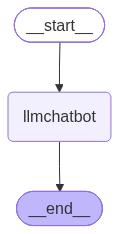

In [7]:
graph_builder = StateGraph(State)
## addiing node
graph_builder.add_node("llmchatbot", chatbot)
## adding edge
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## Compile the graph
graph = graph_builder.compile()
graph

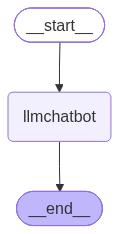

In [8]:
## Visualie the graph
from IPython.display import display, Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [9]:
# graph.invoke({"messages":[{"role": "user", "content": "Hello"}]})
graph.invoke({"messages": "Hello"})

{'messages': [HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}, id='854f3107-4112-401e-9469-5e9a5b031be1'),
  AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hello". We just need to respond appropriately. Probably greet back.'}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 72, 'total_tokens': 108, 'completion_time': 0.077942563, 'completion_tokens_details': {'reasoning_tokens': 18}, 'prompt_time': 0.002748647, 'prompt_tokens_details': None, 'queue_time': 0.212995031, 'total_time': 0.08069121}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c15aa9c1b7', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a945-562a-7c42-9d55-e8cda86240e5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 36, 'total_tokens': 108, 'output_token_details': {'reasoning':

In [10]:
for event in graph.stream({"messages": "Hello, how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I'm doing great, thanks for asking. How can I help you today?


#### Chat bot with tool

In [11]:
# %pip install langchain-tavily

In [12]:
load_dotenv()

True

In [13]:
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [14]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is the capital of France?")

{'query': 'What is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://brainly.in/question/62118432',
   'title': 'What is the capital city of France and why is it famous?',
   'content': 'Answer:\n\nParis is the capital of France, famous for its history, culture, and beauty. Known as the “City of Light,” it has landmarks like the Eiffel Tower, Louvre Museum, and Notre-Dame Cathedral. It is also a world center for art, fashion, and cuisine, attracting millions of tourists every year.\n\n###\n\n###\n\n### New questions in Geography [...] meham495   meham495\n\n Geography\n Secondary School\n\n# What is the capital city of France and why is it famous?\n\nashishrawatrawat14   ashishrawatrawat14\n\nAnswer:\n\nThe capital city of France is Paris.\n\nIt’s famous for several reasons:\n\nCultural heritage – Paris is home to iconic landmarks like the Eiffel Tower, Louvre Museum (housing the Mona Lisa), and Notre-Dame Cathedral.\n\

In [15]:
## custom function
def multiply(x: int, y: int) -> int:
    """Multiply two numbers x and y.
    
    Args:
        x: The first number.
        y: The second number.
        
    Returns:
        The product of x and y.
    """
    return x * y

In [16]:
tools = [tool, multiply]

In [17]:
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000023475E40550>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000023475E40F50>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, an

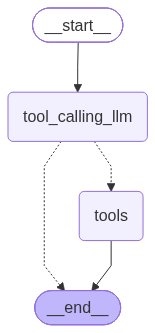

In [18]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state: State) -> State:
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## graph
graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_llm", tool_calling_llm)
graph_builder.add_node("tools", ToolNode(tools))

## Add edges
graph_builder.add_edge(START, "tool_calling_llm")
graph_builder.add_conditional_edges(
    "tool_calling_llm", 
    # if the latest message (result) from assistant is a tool call -> tools_condition route to tools
    # else -> route to END
    tools_condition
    )
graph_builder.add_edge("tools", END)

graph = graph_builder.compile()
graph

In [21]:
response = graph.invoke({"messages": "What is recent AI news?"})


In [22]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_b8ee7ed0-6b80-4fa9-bd30-0282228ee344)
 Call ID: fc_b8ee7ed0-6b80-4fa9-bd30-0282228ee344
  Args:
    query: AI news September 2026
    search_depth: advanced
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.democracynow.org/2026/9/14/headlines", "title": "Headlines for September 14, 2026 | Democracy Now!", "content": "Anthropic’s CEO Dario Amodei called for the development of artificial intelligence to slow down. In a 3,800-word essay published Saturday he called for increased oversight and more guardrails for the technology. His calls were echoed by other AI leaders, inclu

In [25]:
response = graph.invoke({"messages": "What is 5 multiplied by 4?"})

In [26]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 4?
================================== Ai Message ==================================

5 × 4 = 20.


In [27]:
response = graph.invoke({"messages": "What is 5 multiplied by 4 then multiply by 2?"})
for m in response["messages"]:
    m.pretty_print()


================================ Human Message =================================

What is 5 multiplied by 4 then multiply by 2?
================================== Ai Message ==================================

\(5 \times 4 = 20\)

\(20 \times 2 = 40\)

So the result is **40**.


#### REACT agenet architecture

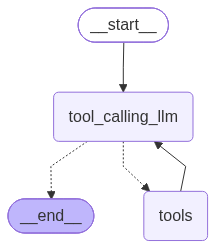

In [28]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state: State) -> State:
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## graph
graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_llm", tool_calling_llm)
graph_builder.add_node("tools", ToolNode(tools))

## Add edges
graph_builder.add_edge(START, "tool_calling_llm")
graph_builder.add_conditional_edges(
    "tool_calling_llm", 
    # if the latest message (result) from assistant is a tool call -> tools_condition route to tools
    # else -> route to END
    tools_condition
    )
graph_builder.add_edge("tools", "tool_calling_llm")
graph_builder.add_edge("tool_calling_llm", END)

graph = graph_builder.compile()
graph

In [29]:
response = graph.invoke({"messages": "Give me the recent AI news and then multiply 5 by 10?"})
for m in response["messages"]:
    m.pretty_print()


================================ Human Message =================================

Give me the recent AI news and then multiply 5 by 10?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_3cdcba3c-7fab-4e55-b65a-9c82c5fbb886)
 Call ID: fc_3cdcba3c-7fab-4e55-b65a-9c82c5fbb886
  Args:
    query: latest AI news September 2026
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.youtube.com/watch?v=sqEsHOid5vU", "title": "AI boss calls for development to slow down | Morning News ...", "content": "# AI boss calls for development to slow down | Morning News Bulletin 13 September 2026\n## SBS News\n648000 subscribers\n1 likes\n\n### Description\n65 views\nPosted: 12 Sep 2026\nIn this bulle

### Adding Memory in Graph

In [32]:
# response = graph.invoke({"messages": "Hello, my name it Atal"})
# for m in response["messages"]:
#     m.pretty_print()

In [33]:
# response = graph.invoke({"messages": "Hello, what is my name"})
# for m in response["messages"]:
#     m.pretty_print()

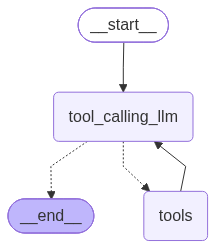

In [40]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

# in memory checkpoint
memory = MemorySaver()

## Node definition
def tool_calling_llm(state: State) -> State:
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## graph
graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_llm", tool_calling_llm)
graph_builder.add_node("tools", ToolNode(tools))

## Add edges
graph_builder.add_edge(START, "tool_calling_llm")
graph_builder.add_conditional_edges(
    "tool_calling_llm", 
    # if the latest message (result) from assistant is a tool call -> tools_condition route to tools
    # else -> route to END
    tools_condition
    )
graph_builder.add_edge("tools", "tool_calling_llm")
graph_builder.add_edge("tool_calling_llm", END)

graph = graph_builder.compile(checkpointer=memory)
graph

In [41]:
config = {"configurable":{"thread_id":1}}
response = graph.invoke({"messages": "Hi, my name is Atal. Give me the recent AI news."}, config=config)
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi, my name is Atal. Give me the recent AI news.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_865a50e5-a078-4d99-96a4-77408d0f5f9f)
 Call ID: fc_865a50e5-a078-4d99-96a4-77408d0f5f9f
  Args:
    query: latest AI news September 2026
    search_depth: advanced
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.youtube.com/watch?v=4o2ribZ-AaU", "title": "AI could \"kill all humans\" within next decade, researchers warn", "content": "# Global National: Sept. 9, 2026 | AI could \"kill all humans\" within next decade, researchers warn\n## Global News\n4910000 subscribers\n55 likes\n\n### Description\n2796 views\nPosted: 10 Sep 2026\nThere are

In [42]:
response = graph.invoke({"messages": "Hi, what is my name?"}, config=config)
print(response["messages"][-1].content)

Your name is **Atal**.


## Streaming

LangGraph graphs expose the stream (sync) and astream (async) methods to yield streamed outputs as iterators. Pass one or more stream modes to control what data you receive.


Use the stream modes updates and values to stream the state of the graph as it executes.
- updates streams the updates to the state after each step of the graph.
- values streams the full value of the state after each step of the graph.

In [43]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
# graph = graph_builder.compile(checkpointer=memory)

def superbot(state: State) -> State:
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

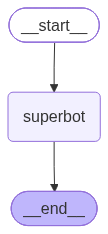

In [45]:
graph = StateGraph(State)

graph.add_node("superbot", superbot)
graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

graph = graph.compile(checkpointer=memory)
graph

In [47]:
config = {"configurable":{"thread_id":1}}
for chunk in graph.stream({"messages": "Hi, my name is Atal. I like playing cricket."}, config=config, stream_mode="updates"):
    print(chunk)
# print(response)

{'superbot': {'messages': [AIMessage(content='Hey Atal! Great to meet a fellow cricket enthusiast. 🏏  \n\nDo you play regularly? If so, what’s your favorite role—batsman, bowler, all‑rounder, or maybe a wicket‑keeper? And are there any teams or players you especially admire? Let’s chat cricket!', additional_kwargs={'reasoning_content': 'The user repeated greeting. Likely wants conversation. We can respond friendly, ask about cricket preferences.'}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 441, 'total_tokens': 536, 'completion_time': 0.203478613, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.032900411, 'prompt_tokens_details': None, 'queue_time': 0.394018596, 'total_time': 0.236379024}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_6c36ac20de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a95e-1e62-7b52-8044-67e9c1473584-0', tool_calls=[], 

In [48]:
config = {"configurable":{"thread_id":1}}
for chunk in graph.stream({"messages": "Hi, my name is Atal. I like playing cricket."}, config=config, stream_mode="values"):
    print(chunk)
# print(response)

{'messages': [HumanMessage(content='Hi, my name is Atal. I like playing cricket.', additional_kwargs={}, response_metadata={}, id='68d16121-a081-4e79-9d64-afcfce9f9130'), AIMessage(content='Nice to meet you, Atal! 🎉 Cricket is such an exciting sport—whether you love batting, bowling, or just cheering from the stands. Do you play yourself, or are you more of a fan? If you’re playing, what role do you usually take on the field?', additional_kwargs={'reasoning_content': 'The user introduced themselves. Likely they want a response, perhaps a conversation. We can respond friendly, ask about cricket. No tool needed.'}, response_metadata={'token_usage': {'completion_tokens': 98, 'prompt_tokens': 359, 'total_tokens': 457, 'completion_time': 0.203233529, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.018181816, 'prompt_tokens_details': None, 'queue_time': 0.214312824, 'total_time': 0.221415345}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_6dedd2be22',

In [51]:
config = {"configurable":{"thread_id":4}}
for chunk in graph.stream({"messages": "Hi, my name is Atal. I like playing cricket."}, config=config, stream_mode="updates"):
    print(chunk)
# print(response)

{'superbot': {'messages': [AIMessage(content='Nice to meet you, Atal! 🎉  \nCricket’s such a fun sport—do you have a favorite team or player? And what role do you usually play on the field?', additional_kwargs={'reasoning_content': 'The user introduced themselves. Probably they want a conversation. Should respond friendly. No specific question. So just greet and ask about cricket.'}, response_metadata={'token_usage': {'completion_tokens': 76, 'prompt_tokens': 359, 'total_tokens': 435, 'completion_time': 0.157763843, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.014514018, 'prompt_tokens_details': None, 'queue_time': 0.40253552, 'total_time': 0.172277861}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_93703442d9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a961-42fc-7e80-912b-c09761191505-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 359, 'output_

In [52]:
config = {"configurable":{"thread_id":4}}
for chunk in graph.stream({"messages": "I also like playing football."}, config=config, stream_mode="values"):
    print(chunk)
# print(response)

{'messages': [HumanMessage(content='Hi, my name is Atal. I like playing cricket.', additional_kwargs={}, response_metadata={}, id='0caac7f4-5e38-4df9-88e1-6a0b85300151'), AIMessage(content='Nice to meet you, Atal! 🎉  \nCricket’s such a fun sport—do you have a favorite team or player? And what role do you usually play on the field?', additional_kwargs={'reasoning_content': 'The user introduced themselves. Probably they want a conversation. Should respond friendly. No specific question. So just greet and ask about cricket.'}, response_metadata={'token_usage': {'completion_tokens': 76, 'prompt_tokens': 359, 'total_tokens': 435, 'completion_time': 0.157763843, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.014514018, 'prompt_tokens_details': None, 'queue_time': 0.40253552, 'total_time': 0.172277861}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_93703442d9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': '

In [ ]:
# config = {"configurable":{"thread_id":5}}
# for chunk in graph.stream({"messages": "Hi, my name is Atal. I like playing cricket."}, config=config, stream_mode="updates"):
#     print(chunk)
# # print(response)